# 07 - Evaluation

All strategies are tested on the same simulated seasons using **common random numbers**. Each policy experiences the same demand and market conditions, so performance differences come from the strategies themselves rather than random variation. This also makes comparisons more reliable.

Seven strategies are compared:

* **Random:** no pricing strategy
* **Naive 1.00x:** always uses the reference price
* **Best fixed:** chooses the best constant price
* **Pace heuristic:** rule-based pricing approach
* **MILP schedule:** fixed schedule from optimisation
* **Double Q-learning:** model-free reinforcement learning
* **DP optimal:** exact model-based optimal policy

In [1]:
import sys

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from plotting import use_style, save_fig, colour

use_style()

import joblib
from scipy import stats
from config import MULTIPLIERS, HORIZON, RESULTS, REGIME_NAMES
from environment import HotelPricingEnv
from metrics import (
    compare,
    paired_tests,
    draw_common_randoms,
    occupancy_paths,
    price_paths,
)
from mdp import dp_policy
import policies as P

In [2]:
env = HotelPricingEnv("City Hotel", "May", seed=0)
Q = np.load(RESULTS / "q_table.npy")
pi_star = np.load(RESULTS / "vi_policy.npy")
schedule = np.load(RESULTS / "lp_schedule.npy")
V_STAR = joblib.load(RESULTS / "vi_solution.joblib")["V_star"]

tune = draw_common_randoms(env, 500, seed=31337)
from metrics import evaluate

fixed_means = [
    evaluate(env, P.fixed_policy(a), tune)["reward"].mean()
    for a in range(env.n_actions)
]
best_a = int(np.argmax(fixed_means))
print(
    f"best constant rate (tuned on a held-out seed stream): {MULTIPLIERS[best_a]:.2f}x"
)

c:\Users\oluwa\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\oluwa\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\oluwa\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.8.0 when using version 1.7.2. This might lead to 

best constant rate (tuned on a held-out seed stream): 1.15x


In [3]:
pace_target = P.naive_pace_curve(HotelPricingEnv("City Hotel", "May", seed=7), n=1500)

strategies = {
    "random": P.random_policy(0),
    "naive 1.00x": P.naive_policy(),
    f"best fixed {MULTIPLIERS[best_a]:.2f}x": P.fixed_policy(best_a),
    "pace heuristic": P.pace_heuristic(pace_target),
    "MILP schedule": P.lp_policy(schedule),
    "Double Q-learning": P.greedy_q_policy(Q),
    "DP optimal": dp_policy(pi_star),
}
summary, raw = compare(env, strategies, n_episodes=4000, seed=777)
summary["vs_naive_%"] = 100 * (
    summary["net_revenue"] / summary.loc["naive 1.00x", "net_revenue"] - 1
)
summary["% of V*"] = 100 * summary["net_revenue"] / V_STAR
summary.round(2)

,net_revenue,ci95,gross_revenue,revpar,adr,occupancy,sell_out_rate,turned_away,mean_multiplier,vs_naive_%,% of V*
strategy,,,,,,,,,,,
random,386329.49,1495.79,389459.27,68.54,69.96,0.98,0.88,328.16,1.07,-13.78,73.05
naive 1.00x,448073.71,452.44,452270.71,79.60,79.60,1.00,1.00,349.75,1.00,0.00,84.73
best fixed 1.15x,457270.23,1493.02,457272.18,80.48,98.31,0.82,0.01,0.14,1.15,2.05,86.47
pace heuristic,443460.53,620.80,448536.58,78.94,78.94,1.00,1.00,425.05,1.06,-1.03,83.86
MILP schedule,510234.43,1236.61,511313.38,89.99,95.73,0.94,0.49,105.78,1.34,13.87,96.48
Double Q-learning,524652.37,664.51,525531.08,92.49,93.41,0.99,0.66,83.13,1.19,17.09,99.21
DP optimal,528570.02,673.81,529357.75,93.16,94.25,0.99,0.62,75.43,1.20,17.96,99.95


## 1. Reading the table

Revenue is not the only measure of performance. The secondary metrics explain why strategies differ.

`naive 1.00x` fills almost all rooms but loses revenue by pricing too low. `best fixed 1.15x` protects price but leaves rooms empty, reaching only 82% occupancy. The learned policies balance both goals: maintaining high prices while still filling rooms by adapting to demand over time.


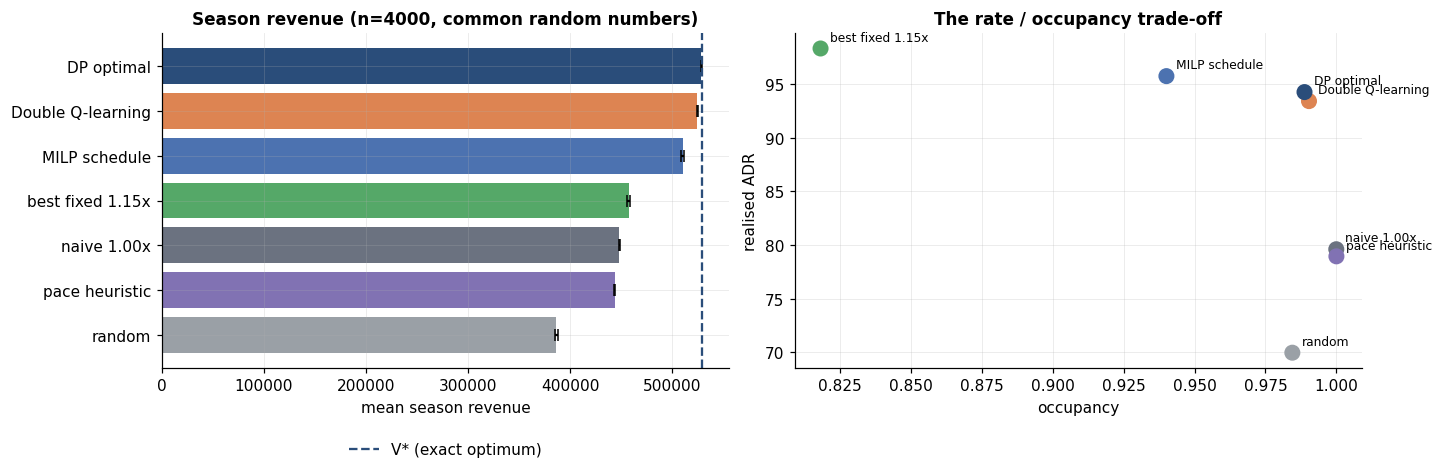

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
order = summary.sort_values("net_revenue").index
colours = [colour(s) for s in order]

axes[0].barh(
    range(len(order)),
    summary.loc[order, "net_revenue"],
    xerr=summary.loc[order, "ci95"],
    color=colours,
    capsize=4,
)
axes[0].axvline(V_STAR, color="#2a4d7a", ls="--", lw=1.5, label="V* (exact optimum)")
axes[0].set(
    yticks=range(len(order)),
    yticklabels=order,
    xlabel="mean season revenue",
    title="Season revenue (n=4000, common random numbers)",
)
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18))

axes[1].scatter(
    summary["occupancy"],
    summary["adr"],
    s=90,
    c=[colour(s) for s in summary.index],
    zorder=3,
)
for name, row in summary.iterrows():
    axes[1].annotate(
        name,
        (row["occupancy"], row["adr"]),
        textcoords="offset points",
        xytext=(6, 5),
        fontsize=8,
    )
axes[1].set(
    xlabel="occupancy", ylabel="realised ADR", title="The rate / occupancy trade-off"
)
save_fig("07_strategy_comparison")
plt.show()

## 2. Significance

Strategies are compared against list pricing using paired t-tests, with Holm correction and Cohen’s d to measure effect size.

With 4,000 simulations, statistical significance is easy to achieve, so the effect size is more important. A Cohen’s d above 0.8 indicates a large improvement. The learned policies show large effects, while the pace heuristic shows a much smaller impact.

In [5]:
tests = paired_tests(raw, "naive 1.00x")
tests.round(4)

,mean_diff,lift_pct,t,p_raw,cohens_d,p_holm,significant_05
strategy,,,,,,,
random,-61744.2120,-13.7799,-80.0107,0.0,-1.2651,0.0,True
MILP schedule,62160.7236,13.8729,81.4998,0.0,1.2886,0.0,True
Double Q-learning,76578.6640,17.0906,152.3979,0.0,2.4096,0.0,True
DP optimal,80496.3111,17.9650,159.0171,0.0,2.5143,0.0,True
best fixed 1.15x,9196.5271,2.0525,9.8141,0.0,0.1552,0.0,True
pace heuristic,-4613.1756,-1.0296,-9.5258,0.0,-0.1506,0.0,True


In [6]:
best_fixed_name = f"best fixed {MULTIPLIERS[best_a]:.2f}x"
head_to_head = paired_tests(
    {
        k: raw[k]
        for k in ["Double Q-learning", best_fixed_name, "MILP schedule", "DP optimal"]
    },
    best_fixed_name,
)
print("Is the learned policy better than the best constant rate?\n")
print(head_to_head.round(4).to_string())

Is the learned policy better than the best constant rate?

                    mean_diff  lift_pct         t  p_raw  cohens_d  p_holm  significant_05
strategy                                                                                  
Double Q-learning  67382.1369   14.7357  139.5329    0.0    2.2062     0.0            True
MILP schedule      52964.1965   11.5827  130.9174    0.0    2.0700     0.0            True
DP optimal         71299.7839   15.5925  151.9994    0.0    2.4033     0.0            True


## 3. How the strategies behave over the season

Average revenue hides how each strategy works over time. The booking pace shows when rooms are filled, while the price path shows how rates change.

The learned policies lower prices early to build demand, then increase rates as availability becomes limited. Fixed strategies cannot adjust and therefore miss these demand changes.

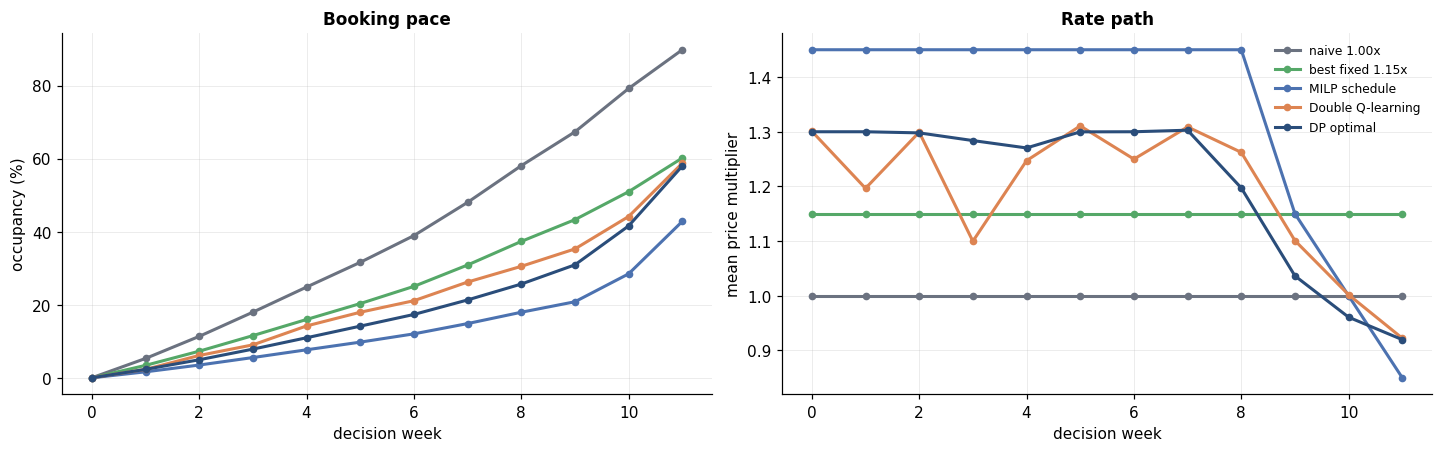

In [7]:
paths_commons = draw_common_randoms(env, 800, seed=2024)
shown = ["naive 1.00x", best_fixed_name, "MILP schedule", "Double Q-learning", "DP optimal"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name in shown:
    occ = np.nanmean(occupancy_paths(env, strategies[name], paths_commons), axis=0)
    prc = np.nanmean(price_paths(env, strategies[name], paths_commons), axis=0)
    axes[0].plot(range(HORIZON), 100 * occ, "o-", lw=2, color=colour(name), label=name, ms=4)
    axes[1].plot(range(HORIZON), prc, "o-", lw=2, color=colour(name), label=name, ms=4)
axes[0].set(xlabel="decision week", ylabel="occupancy (%)", title="Booking pace")
axes[1].set(xlabel="decision week", ylabel="mean price multiplier", title="Rate path")
axes[1].legend(fontsize=8)
save_fig("07_season_dynamics")
plt.show()

## 4. Robustness to Elasticity

Elasticity is the most uncertain input, so the policies are tested across a range of elasticity values to see if the results remain consistent.

The DP policy is recalculated for each elasticity because it uses the model directly. The Q-learning policy is kept unchanged, showing how sensitive a deployed agent is to an incorrect elasticity estimate.

In [8]:
from mdp import value_iteration, optimal_value

rows = []
for eps in [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
    e = HotelPricingEnv("City Hotel", "May", elasticity=eps, seed=0)
    v, pol, _ = value_iteration(e)
    strat = {
        "naive 1.00x": P.naive_policy(),
        "best fixed": P.fixed_policy(best_a),
        "Double Q-learning": P.greedy_q_policy(Q),
        "DP optimal": dp_policy(pol),
    }
    s, _ = compare(e, strat, n_episodes=800, seed=777)
    base = s.loc["naive 1.00x", "net_revenue"]
    rows.append(
        {
            "elasticity": eps,
            "best fixed": 100 * (s.loc["best fixed", "net_revenue"] / base - 1),
            "Double Q-learning": 100
            * (s.loc["Double Q-learning", "net_revenue"] / base - 1),
            "DP optimal": 100 * (s.loc["DP optimal", "net_revenue"] / base - 1),
        }
    )
robustness = pd.DataFrame(rows).set_index("elasticity")
robustness.round(1)

,best fixed,Double Q-learning,DP optimal
elasticity,,,
1.5,18.6,22.7,26.5
2.0,15.8,20.1,21.7
2.5,10.5,18.2,19.3
3.0,3.7,17.2,17.9
3.5,-3.3,15.5,16.9
4.0,-9.8,12.7,16.4


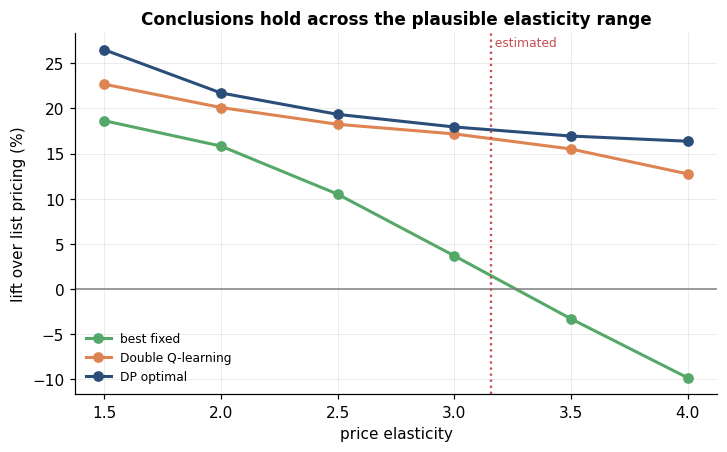

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for name in robustness.columns:
    ax.plot(
        robustness.index, robustness[name], "o-", lw=2, color=colour(name), label=name
    )
ax.axhline(0, color="grey", lw=1)
ax.axvline(env.elasticity, color="#c44e52", ls=":", lw=1.5)
ax.text(
    env.elasticity, ax.get_ylim()[1] * 0.95, " estimated", color="#c44e52", fontsize=8
)
ax.set(
    xlabel="price elasticity",
    ylabel="lift over list pricing (%)",
    title="Conclusions hold across the plausible elasticity range",
)
ax.legend(fontsize=8)
save_fig("07_elasticity_robustness")
plt.show()

## 5. Generalisation Across All 24 Cells

The previous results focused only on City Hotel in May. Testing all 24 hotel-month combinations shows whether the approach generalises beyond one case.  

The Q-table trained on City/May is applied unchanged to all other cells, providing a true zero-shot transfer test.

In [10]:
from config import MONTH_ORDER

records = []
for hotel in ["City Hotel", "Resort Hotel"]:
    for month in MONTH_ORDER:
        e = HotelPricingEnv(hotel, month, seed=0)
        v, pol, _ = value_iteration(e)
        s, _ = compare(
            e,
            {
                "naive 1.00x": P.naive_policy(),
                "best fixed": P.fixed_policy(best_a),
                "Double Q-learning": P.greedy_q_policy(Q),
                "DP optimal": dp_policy(pol),
            },
            n_episodes=300,
            seed=777,
        )
        base = s.loc["naive 1.00x", "net_revenue"]
        records.append(
            {
                "hotel": hotel,
                "month": month,
                "best fixed": 100 * (s.loc["best fixed", "net_revenue"] / base - 1),
                "Double Q-learning": 100
                * (s.loc["Double Q-learning", "net_revenue"] / base - 1),
                "DP optimal": 100 * (s.loc["DP optimal", "net_revenue"] / base - 1),
            }
        )
generalisation = pd.DataFrame(records)
generalisation.groupby("hotel")[
    ["best fixed", "Double Q-learning", "DP optimal"]
].mean().round(1)

,best fixed,Double Q-learning,DP optimal
hotel,,,
City Hotel,10.3,23.6,27.0
Resort Hotel,31.5,43.1,56.8


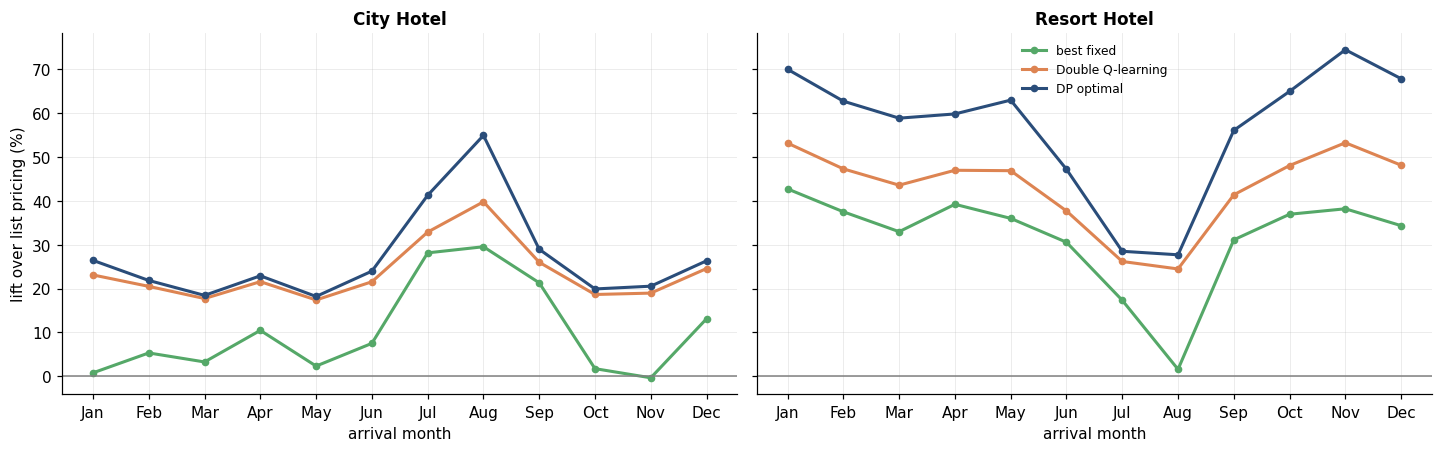

zero-shot Q-learning lift across 24 cells: median 29.5%, range 17.4% to 53.3%
cells where it beats list pricing: 24/24


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, hotel in zip(axes, ["City Hotel", "Resort Hotel"]):
    sub = generalisation[generalisation["hotel"] == hotel].set_index("month")
    sub = sub.reindex(MONTH_ORDER)
    for name in ["best fixed", "Double Q-learning", "DP optimal"]:
        ax.plot(range(12), sub[name], "o-", lw=2, color=colour(name), label=name, ms=4)
    ax.axhline(0, color="grey", lw=1)
    ax.set(title=hotel, xticks=range(12),
           xticklabels=[m[:3] for m in MONTH_ORDER], xlabel="arrival month")
axes[0].set_ylabel("lift over list pricing (%)")
axes[1].legend(fontsize=8)
save_fig("07_generalisation")
plt.show()

lifts = generalisation["Double Q-learning"]
print(f"zero-shot Q-learning lift across 24 cells: median {lifts.median():.1f}%, "
      f"range {lifts.min():.1f}% to {lifts.max():.1f}%")
print(f"cells where it beats list pricing: {(lifts > 0).sum()}/24")

## 6. Summary of Findings

* **Dynamic pricing wins:** The optimal policy outperforms the best fixed price by adapting to inventory and demand conditions.

* **Both algorithms work:** Value Iteration finds the exact solution, while Double Q-learning achieves ~99% of it using only simulated experience. The remaining gap comes from state simplification and learning error.

* **Adaptive beats fixed planning:** The MILP schedule looks strong under expected demand but performs worse under real uncertainty because it cannot react.

* **Simple rules are limited:** The pace heuristic underperforms because reacting to occupancy alone is not enough; pricing must balance demand and revenue.

* **Key limitation:** Elasticity estimates are uncertain, and the simulator does not model customers delaying bookings in response to future discounts.

In [12]:
final = summary[["net_revenue", "gross_revenue", "ci95", "revpar", "adr", "occupancy", "sell_out_rate",
                 "vs_naive_%", "% of V*"]].sort_values("net_revenue", ascending=False)
final.round(2).to_csv(RESULTS / "final_comparison.csv")
joblib.dump({"summary": summary, "tests": tests, "robustness": robustness,
             "generalisation": generalisation}, RESULTS / "evaluation.joblib")
final.round(2)

,net_revenue,gross_revenue,ci95,revpar,adr,occupancy,sell_out_rate,vs_naive_%,% of V*
strategy,,,,,,,,,
DP optimal,528570.02,529357.75,673.81,93.16,94.25,0.99,0.62,17.96,99.95
Double Q-learning,524652.37,525531.08,664.51,92.49,93.41,0.99,0.66,17.09,99.21
MILP schedule,510234.43,511313.38,1236.61,89.99,95.73,0.94,0.49,13.87,96.48
best fixed 1.15x,457270.23,457272.18,1493.02,80.48,98.31,0.82,0.01,2.05,86.47
naive 1.00x,448073.71,452270.71,452.44,79.60,79.60,1.00,1.00,0.00,84.73
pace heuristic,443460.53,448536.58,620.80,78.94,78.94,1.00,1.00,-1.03,83.86
random,386329.49,389459.27,1495.79,68.54,69.96,0.98,0.88,-13.78,73.05
